<a href="https://colab.research.google.com/github/TeachFeastKunal/OIBSIP/blob/main/SalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
import kagglehub
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report , mean_absolute_error , mean_squared_error , r2_score
from datetime import date

In [5]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [7]:
csv_path = kagglehub.dataset_download('bumba5341/advertisingcsv')
file_path = os.listdir(csv_path)[0]

Using Colab cache for faster access to the 'advertisingcsv' dataset.


In [18]:
df = pd.read_csv(os.path.join(csv_path , file_path))
df = df.drop('Unnamed: 0' , axis = 1)
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


### Check For Linearity

[]

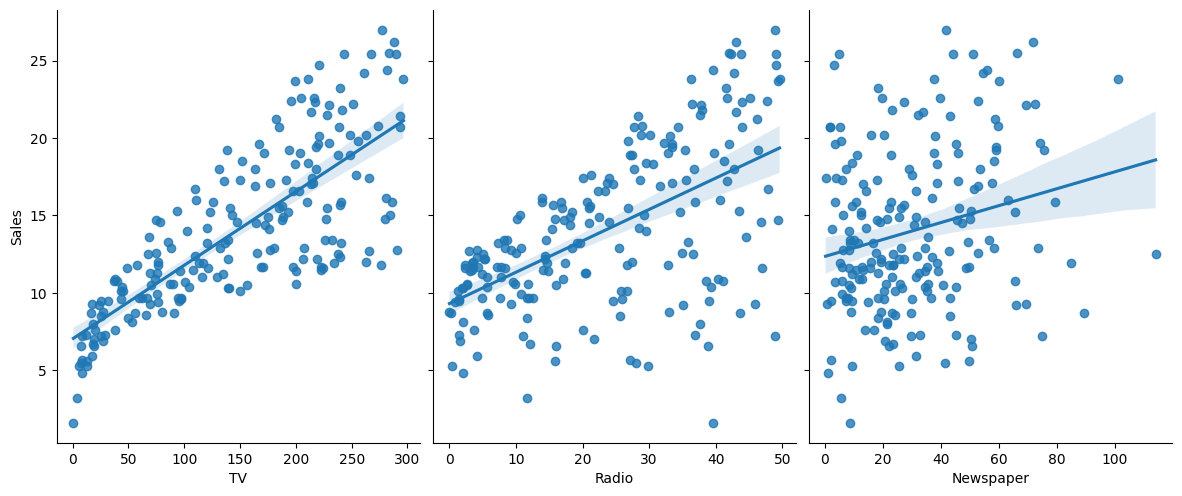

In [32]:
sns.pairplot(data = df , x_vars = ['TV' , 'Radio' , 'Newspaper'] , y_vars = 'Sales' , aspect= 0.8 , height = 5 , kind = 'reg')
plt.plot()

##Modelling

In [38]:
x = df[['TV' , 'Radio' , 'Newspaper']]
y =  df['Sales']

x_train , x_test , y_train , y_test = train_test_split(x ,y , test_size = 0.3 , random_state = 10)


model = LinearRegression()
model.fit(x_train , y_train)

y_pred = model.predict(x_test)


## Model Evaluation

In [39]:
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test , y_pred)
r2score = r2_score(y_test , y_pred)

print('mse' , mse)
print('rmse' , rmse)
print('mae' , mae)
print('r2score' , r2score)

mse 5.374051588095292
rmse 2.318200075078787
mae 1.7091210770106207
r2score 0.8567790678044409


In [40]:
x_with_const = sm.add_constant(x)

stat_model = sm.OLS(y , x_with_const).fit()
stat_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        18:54:49   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Model Visualization

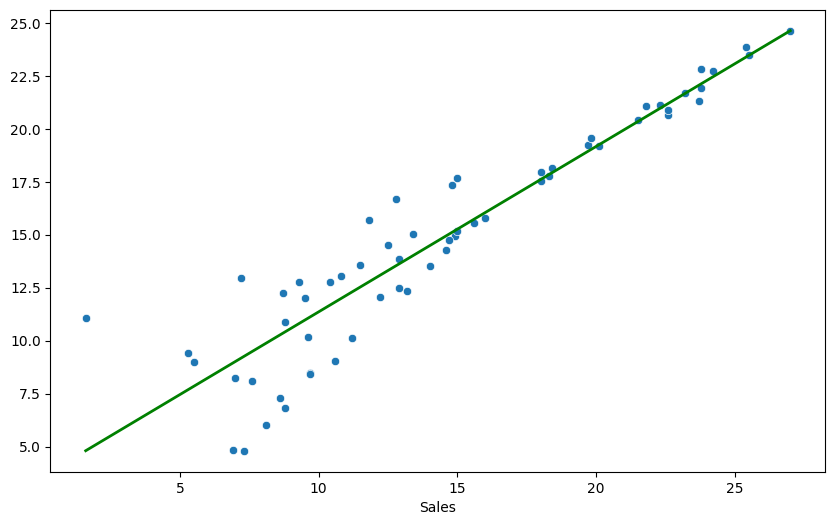

In [44]:
fig , axs = plt.subplots(1,1 , figsize = (10,6))

sns.scatterplot(x = y_test , y = y_pred , ax =axs )
sns.lineplot(ax = axs , x = [y_test.min() , y_test.max()] , y = [y_pred.min() , y_pred.max()] , lw = 2 , color = 'green')
plt.show()